# Matplotlib Phase 1: The Canvas (Foundations)
### Credit Card Risk Analysis Project

Welcome to Matplotlib! In pandas you learned to **shape and understand** your data.
Now you'll learn to **communicate** it. A risk model is only as useful as the story
you can tell a stakeholder about it — and that story is almost always told with a chart.

This notebook covers 4 topics:
1. **The Object-Oriented Approach** — Figure vs. Axes
2. **Basic Line Plots** — plotting trends over time
3. **Chart Anatomy** — titles, labels, and making charts legible
4. **Aesthetics & Readability** — colors, gridlines, legends

**Format:** Each question has a `YOUR CODE HERE` cell to attempt first, followed by a
`Solution` cell. Try to write your own answer before peeking!

Run the setup cell below first — it creates the synthetic dataset used throughout.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Total loan applications received per month
loan_applications = np.array([1200, 1350, 1280, 1450, 1600, 1550,
                               1700, 1650, 1800, 1750, 1900, 2100])

# Applications broken down by risk tier (sums to loan_applications)
low_risk    = np.array([700, 780, 750, 820, 900, 880, 950, 930, 1000, 970, 1050, 1150])
medium_risk = np.array([400, 450, 430, 480, 530, 510, 570, 550, 600, 580, 630, 700])
high_risk   = loan_applications - low_risk - medium_risk

# Portfolio default rate (%) per month
default_rate = np.array([3.2, 3.5, 3.1, 3.8, 4.0, 3.9, 4.3, 4.1, 4.5, 4.2, 4.6, 5.0])

print("Setup complete.")
print(f"Months: {len(months)}, Applications shape: {loan_applications.shape}")


Setup complete.
Months: 12, Applications shape: (12,)


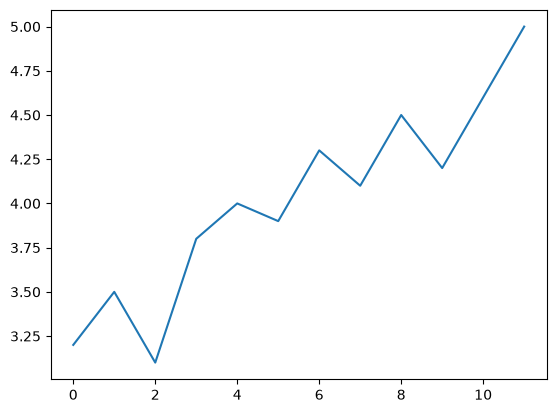

In [9]:
plt.plot(default_rate)

---
## Section 1: The Object-Oriented Approach

Matplotlib has two interfaces: the quick **pyplot (state-based)** interface (`plt.plot(...)`),
and the **object-oriented (OO)** interface, where you explicitly hold references to a
`Figure` (the whole window/canvas) and one or more `Axes` (the individual plots living
inside it). For anything beyond a single throwaway chart — dashboards, reports,
multi-panel comparisons — the OO approach is the professional standard, so we'll use it
throughout this project.


**Q1.** Create a Figure and a single Axes using `plt.subplots()`, storing them in `fig` and `ax`. Print `type(fig)` and `type(ax)`.

In [4]:
# YOUR CODE HERE
fig, ax=plt.subplots()
print(plt.close(fig))

None


**Solution 1**

In [5]:
fig, ax = plt.subplots()
print(type(fig))
print(type(ax))
plt.close(fig)


<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


**Q2.** Create a Figure with 1 row and 2 columns of subplots using `plt.subplots(1, 2)`. Print the `.shape` of the resulting `axes` array and its `type`.

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

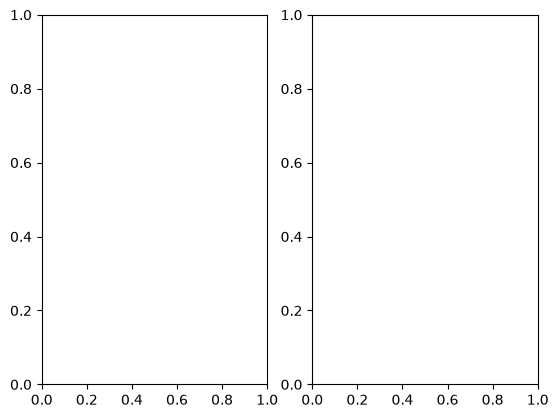

In [ ]:
# YOUR CODE HERE
# plt.subplots(1,2)


**Solution 2**

In [ ]:
fig, axes = plt.subplots(1, 2)
print(axes.shape)
print(type(axes))
plt.close(fig)


**Q3.** Create a single Figure/Axes pair sized 10 inches wide by 6 inches tall using the `figsize` parameter. Print `fig.get_size_inches()` to confirm.

In [ ]:
# YOUR CODE HERE


**Solution 3**

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
print(fig.get_size_inches())
plt.close(fig)


**Q4.** Create a Figure with a 2x2 grid of subplots. Print `len(fig.axes)` to show how many Axes objects the Figure is tracking.

In [ ]:
# YOUR CODE HERE


**Solution 4**

In [ ]:
fig, axes = plt.subplots(2, 2)
print(len(fig.axes))
plt.close(fig)


**Q5.** Create a Figure with 2 rows and 1 column (`figsize=(8, 8)`). On `axes[0]`, plot `loan_applications` against `months`. On `axes[1]`, plot `default_rate` against `months`. This is the core OO pattern: call `.plot()` directly on the Axes object, not on `plt`.

In [ ]:
# YOUR CODE HERE


**Solution 5**

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
axes[0].plot(months, loan_applications)
axes[1].plot(months, default_rate)
plt.show()


**Q6.** Create a Figure/Axes pair, plot `loan_applications`, then use `fig.suptitle()` (a Figure-level method, not an Axes-level one) to add the overall title `"Loan Portfolio Dashboard"`.

In [ ]:
# YOUR CODE HERE


**Solution 6**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
fig.suptitle("Loan Portfolio Dashboard")
plt.show()


**Q7.** Create a Figure/Axes pair, plot `loan_applications`, and save it to disk as `monthly_applications.png` using `fig.savefig()` — the OO equivalent of `plt.savefig()`. Print a confirmation message after saving.

In [ ]:
# YOUR CODE HERE


**Solution 7**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
fig.savefig("monthly_applications.png")
print("Saved monthly_applications.png")
plt.close(fig)


> **Checkpoint — Section 1:** `plt.subplots()` gives you a `Figure` (the container/canvas)
> and one or more `Axes` (the actual plots). Everything downstream — titles, labels, styling —
> gets called as a method *on the Axes* (`ax.set_title()`, `ax.plot()`) or *on the Figure*
> (`fig.suptitle()`, `fig.savefig()`). Keep that distinction in mind going forward.


---
## Section 2: Basic Line Plots

Line plots are the default choice for showing a trend over time — exactly what a risk
analyst needs when reporting on application volume, default rates, or portfolio growth
month over month.


**Q8.** Create a Figure/Axes pair and plot `loan_applications` against `months` using `ax.plot()`.

In [ ]:
# YOUR CODE HERE


**Solution 8**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
plt.show()


**Q9.** Repeat the plot from Q8, but this time add a circular marker at each data point using the `marker='o'` parameter.

In [ ]:
# YOUR CODE HERE


**Solution 9**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications, marker='o')
plt.show()


**Q10.** On the same Axes, plot both `low_risk` and `medium_risk` against `months` (call `ax.plot()` twice on the same `ax`).

In [ ]:
# YOUR CODE HERE


**Solution 10**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, low_risk)
ax.plot(months, medium_risk)
plt.show()


**Q11.** Plot `default_rate` against `months` using a dashed line (`linestyle='--'`).

In [ ]:
# YOUR CODE HERE


**Solution 11**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, default_rate, linestyle='--')
plt.show()


**Q12.** Compute the running total of loan applications through the year using `np.cumsum(loan_applications)`, then plot that cumulative series against `months`.

In [ ]:
# YOUR CODE HERE


**Solution 12**

In [ ]:
cumulative_applications = np.cumsum(loan_applications)
fig, ax = plt.subplots()
ax.plot(months, cumulative_applications)
plt.show()


**Q13.** Create a Figure with 2 rows, 1 column, and `sharex=True` so both subplots line up on the same x-axis. Plot `loan_applications` on the top Axes and `default_rate` on the bottom Axes.

In [ ]:
# YOUR CODE HERE


**Solution 13**

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(months, loan_applications)
axes[1].plot(months, default_rate)
plt.show()


**Q14.** On one Axes, draw `loan_applications` as a line (`ax.plot()`) and overlay individual points using `ax.scatter()` on top of it — combining a line plot and a scatter plot on the same Axes.

In [ ]:
# YOUR CODE HERE


**Solution 14**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
ax.scatter(months, loan_applications)
plt.show()


> **Checkpoint — Section 2:** `ax.plot()` is your main tool for trends over time, and you
> can call it multiple times on the same Axes to overlay series. Markers, linestyles, and
> combining plot types (line + scatter) are all just extra parameters or extra calls —
> nothing about the underlying pattern changes.


---
## Section 3: Chart Anatomy

A chart with no title or axis labels is close to useless to a stakeholder — they
shouldn't have to guess what the numbers mean. This section is about making every
chart self-explanatory.


**Q15.** Plot `loan_applications` against `months`, then add the title `"Monthly Loan Applications"` using `ax.set_title()`.

In [ ]:
# YOUR CODE HERE


**Solution 15**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
ax.set_title("Monthly Loan Applications")
plt.show()


**Q16.** Repeat Q15, and additionally label the x-axis `"Month"` and the y-axis `"Number of Applications"` using `ax.set_xlabel()` and `ax.set_ylabel()`.

In [ ]:
# YOUR CODE HERE


**Solution 16**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
ax.set_title("Monthly Loan Applications")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Applications")
plt.show()


**Q17.** Repeat Q16, but make the title stand out by passing `fontsize=14` and `fontweight='bold'` to `ax.set_title()`.

In [ ]:
# YOUR CODE HERE


**Solution 17**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)
ax.set_title("Monthly Loan Applications", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Number of Applications")
plt.show()


**Q18.** Plot `default_rate` against `months`. The month labels can get cramped — use `ax.set_xticks()` with `range(len(months))` and `ax.set_xticklabels(months, rotation=45)` to rotate them 45 degrees for readability.

In [ ]:
# YOUR CODE HERE


**Solution 18**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, default_rate)
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45)
plt.show()


**Q19.** Plot `default_rate` against `months`, then force the y-axis to always start at 0 and end at 6 using `ax.set_ylim(0, 6)`. This matters for risk reporting — a truncated y-axis can visually exaggerate small changes in default rate.

In [ ]:
# YOUR CODE HERE


**Solution 19**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, default_rate)
ax.set_ylim(0, 6)
plt.show()


**Q20.** Plot `loan_applications` against `months`. Find the month with the peak value (hint: `np.argmax`), then use `ax.annotate()` to label that point `"Peak"` with an arrow pointing at it (use the `xy` and `xytext` parameters).

In [ ]:
# YOUR CODE HERE


**Solution 20**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications)

peak_idx = np.argmax(loan_applications)
ax.annotate(
    "Peak",
    xy=(peak_idx, loan_applications[peak_idx]),
    xytext=(peak_idx - 2, loan_applications[peak_idx] + 150),
    arrowprops=dict(facecolor='black', arrowstyle='->')
)
plt.show()


**Q21.** Create a Figure with 2 rows, 1 column, `sharex=True`. Top Axes: plot `loan_applications`, with `ax.set_title("Applications")` and `ax.set_ylabel("Count")`. Bottom Axes: plot `default_rate`, with `ax.set_title("Default Rate")` and `ax.set_ylabel("Percent")`. Add an overall `fig.suptitle("Monthly Risk Overview")`.

In [ ]:
# YOUR CODE HERE


**Solution 21**

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(months, loan_applications)
axes[0].set_title("Applications")
axes[0].set_ylabel("Count")

axes[1].plot(months, default_rate)
axes[1].set_title("Default Rate")
axes[1].set_ylabel("Percent")

fig.suptitle("Monthly Risk Overview")
plt.show()


> **Checkpoint — Section 3:** `set_title()`, `set_xlabel()`, and `set_ylabel()` are Axes-level
> calls that turn a bare line into a chart someone else can actually interpret. `set_xticks()`
> / `set_xticklabels()` fix crowded category labels, `set_ylim()` gives you control over how
> dramatic (or not) a trend looks, and `annotate()` lets you call out a specific point directly
> on the chart.


---
## Section 4: Aesthetics & Readability

The last piece is making the chart pleasant and unambiguous to read — especially once
you're plotting multiple series (like risk tiers) on the same Axes.


**Q22.** Plot `loan_applications` against `months` using the color `'darkred'` (pass `color='darkred'` to `ax.plot()`).

In [ ]:
# YOUR CODE HERE


**Solution 22**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, loan_applications, color='darkred')
plt.show()


**Q23.** Plot `default_rate` against `months`, then add gridlines using `ax.grid(True)` to make it easier to read off exact values.

In [ ]:
# YOUR CODE HERE


**Solution 23**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, default_rate)
ax.grid(True)
plt.show()


**Q24.** On one Axes, plot `low_risk`, `medium_risk`, and `high_risk` against `months` as three separate lines, giving each a distinct `color` and a `label` (e.g. `label='Low Risk'`). Then call `ax.legend()` so the three lines can be told apart.

In [ ]:
# YOUR CODE HERE


**Solution 24**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, low_risk, color='green', label='Low Risk')
ax.plot(months, medium_risk, color='orange', label='Medium Risk')
ax.plot(months, high_risk, color='red', label='High Risk')
ax.legend()
plt.show()


**Q25.** Repeat Q24, but this time customize the legend's placement with `loc='upper left'` and remove its border box with `frameon=False`.

In [ ]:
# YOUR CODE HERE


**Solution 25**

In [ ]:
fig, ax = plt.subplots()
ax.plot(months, low_risk, color='green', label='Low Risk')
ax.plot(months, medium_risk, color='orange', label='Medium Risk')
ax.plot(months, high_risk, color='red', label='High Risk')
ax.legend(loc='upper left', frameon=False)
plt.show()


**Q26.** Apply the built-in `'seaborn-v0_8-whitegrid'` style with `plt.style.use()` (falling back to `'ggplot'` if that style name isn't available in your Matplotlib version), then re-plot the three risk-tier lines from Q24. Notice how much cleaner a professional style palette looks with zero extra effort.

In [ ]:
# YOUR CODE HERE


**Solution 26**

In [ ]:
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

fig, ax = plt.subplots()
ax.plot(months, low_risk, label='Low Risk')
ax.plot(months, medium_risk, label='Medium Risk')
ax.plot(months, high_risk, label='High Risk')
ax.legend()
plt.show()

plt.style.use('default')  # reset for later cells


**Q27 (Capstone).** Bring everything from this notebook together into one polished chart. On a single Figure/Axes:
- Plot `low_risk`, `medium_risk`, and `high_risk` against `months`, each with a distinct color and a label
- Add `ax.set_title()` with a bold, readable title
- Add `ax.set_xlabel()` and `ax.set_ylabel()`
- Rotate the x-tick labels 45 degrees
- Turn on gridlines
- Add a legend
- Add an `fig.suptitle()`

This is the kind of chart you'd actually put in front of a credit risk committee.

In [ ]:
# YOUR CODE HERE


**Solution 27**

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(months, low_risk, color='green', marker='o', label='Low Risk')
ax.plot(months, medium_risk, color='orange', marker='o', label='Medium Risk')
ax.plot(months, high_risk, color='red', marker='o', label='High Risk')

ax.set_title("Loan Applications by Risk Tier", fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Number of Applications")
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=False)

fig.suptitle("Executive Loan Dashboard", fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()


---
## Checkpoint: Phase 1 Complete

You've covered:
- **The OO approach** — `Figure` (the canvas) vs. `Axes` (the plot), and why you should
  reach for `fig, ax = plt.subplots()` instead of the quick `plt.plot()` shortcut
- **Basic line plots** — `ax.plot()`, markers, linestyles, multiple series on one Axes,
  and multi-panel figures with `sharex=True`
- **Chart anatomy** — `set_title()`, `set_xlabel()`, `set_ylabel()`, tick rotation,
  `set_ylim()`, and `annotate()`
- **Aesthetics** — colors, `grid()`, `legend()` placement, and style sheets

**Next up (Phase 2):** other core chart types for risk analysis — bar charts (for
comparing categories like risk tiers or employment types), histograms (for distributions
like credit score or loan amount), and possibly box plots for outlier detection.

Let me know when you're ready to move on!
